In [2]:
!pip install multiSyncPy

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal, stats

from multiSyncPy.synchrony_metrics import (
    rho,
    apply_windowed,
)

In [4]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("PROCESSED_DIR:", PROCESSED_DIR)

PROCESSED_DIR: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed


In [5]:
SEGMENTS = ["pre_meditation", "main_meditation", "recovery"]

VALID_EMOTIBIT_IDS = [
    "EmotiBit_1",
    "EmotiBit_2",
    "EmotiBit_3",
    "EmotiBit_4",
    "EmotiBit_6",
    "EmotiBit_7",
]

CANDIDATE_CLUSTER = ["EmotiBit_4", "EmotiBit_6", "EmotiBit_7"]

# Window settings (1 Hz HR data)
WINDOW_LENGTH = 30   # seconds
WINDOW_STEP = 5      # seconds

In [6]:
def load_group_hr(segment):
    path = PROCESSED_DIR / f"group_hr_{segment}_aligned_1s.csv"
    if not path.exists():
        return None, path
    return pd.read_csv(path), path


def zscore_rows(data):
    """
    data shape = (n_signals, duration)
    z-score each signal separately.
    """
    out = []
    for row in data:
        z = stats.zscore(row, nan_policy="omit")
        out.append(z)
    return np.asarray(out, dtype=float)


def dataframe_to_multisync_matrix(df, subject_cols):
    """
    multiSyncPy expects shape (number_signals, duration)
    """
    x = df[subject_cols].to_numpy(dtype=float).T
    return x


def phase_matrix_from_signals(data):
    """
    Convert each signal to instantaneous phase using Hilbert transform.
    Input shape: (n_signals, duration)
    Output shape: (n_signals, duration)
    """
    phase_rows = []
    for row in data:
        analytic = signal.hilbert(row)
        phase_rows.append(np.angle(analytic))
    return np.asarray(phase_rows)


def compute_rho_summary(data):
    """
    data shape = (n_signals, duration)
    Returns rho time series and rho average.
    """
    phases = phase_matrix_from_signals(data)
    rho_ts, rho_avg = rho(phases)

    return {
        "rho_ts": np.asarray(rho_ts, dtype=float),
        "rho_mean": float(rho_avg),
        "rho_ts_mean": float(np.mean(rho_ts)),
        "rho_ts_std": float(np.std(rho_ts, ddof=1)) if len(rho_ts) > 1 else np.nan,
    }


def rho_only(data):
    """
    Helper for apply_windowed.
    Returns one scalar rho average for a window.
    """
    phases = phase_matrix_from_signals(data)
    _, rho_avg = rho(phases)
    return float(rho_avg)

In [7]:
segment_data = {}

for segment in SEGMENTS:
    df, path = load_group_hr(segment)
    if df is None:
        print("Missing:", path)
        continue

    subject_cols = [c for c in VALID_EMOTIBIT_IDS if c in df.columns]

    full_data = dataframe_to_multisync_matrix(df, subject_cols)
    full_data = zscore_rows(full_data)

    cluster_data = dataframe_to_multisync_matrix(df, CANDIDATE_CLUSTER)
    cluster_data = zscore_rows(cluster_data)

    segment_data[segment] = {
        "df": df,
        "subject_cols": subject_cols,
        "full_data": full_data,
        "cluster_data": cluster_data,
    }

    print(segment, "full_data shape:", full_data.shape, "cluster_data shape:", cluster_data.shape)

pre_meditation full_data shape: (6, 242) cluster_data shape: (3, 242)
main_meditation full_data shape: (6, 752) cluster_data shape: (3, 752)
recovery full_data shape: (6, 93) cluster_data shape: (3, 93)


In [8]:
rows = []

for segment in SEGMENTS:
    if segment not in segment_data:
        continue

    full_result = compute_rho_summary(segment_data[segment]["full_data"])
    cluster_result = compute_rho_summary(segment_data[segment]["cluster_data"])

    rows.append({
        "segment": segment,
        "whole_rho_mean": full_result["rho_mean"],
        "whole_rho_ts_mean": full_result["rho_ts_mean"],
        "whole_rho_ts_std": full_result["rho_ts_std"],
        "cluster467_rho_mean": cluster_result["rho_mean"],
        "cluster467_rho_ts_mean": cluster_result["rho_ts_mean"],
        "cluster467_rho_ts_std": cluster_result["rho_ts_std"],
    })

rho_summary = pd.DataFrame(rows)
display(rho_summary)

,segment,whole_rho_mean,whole_rho_ts_mean,whole_rho_ts_std,cluster467_rho_mean,cluster467_rho_ts_mean,cluster467_rho_ts_std
0,pre_meditation,0.377058,0.377058,0.196335,0.537006,0.537006,0.233914
1,main_meditation,0.417731,0.417731,0.190428,0.645230,0.645230,0.246436
2,recovery,0.404090,0.404090,0.179660,0.491454,0.491454,0.215616


In [9]:
out_path = TABLES_DIR / "multisyncpy_rho_summary.csv"
rho_summary.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/multisyncpy_rho_summary.csv


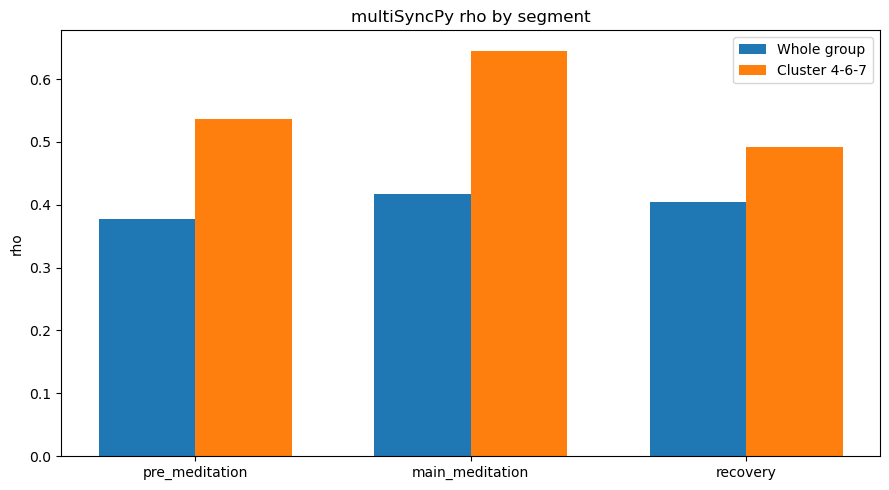

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/multisyncpy_rho_by_segment.png


In [10]:
plot_df = rho_summary.copy()
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, plot_df["whole_rho_mean"], width, label="Whole group")
plt.bar(x + width/2, plot_df["cluster467_rho_mean"], width, label="Cluster 4-6-7")

plt.xticks(x, plot_df["segment"])
plt.ylabel("rho")
plt.title("multiSyncPy rho by segment")
plt.legend()
plt.tight_layout()

out_path = FIGURES_DIR / "multisyncpy_rho_by_segment.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [11]:
window_rows = []

for segment in SEGMENTS:
    if segment not in segment_data:
        continue

    full_data = segment_data[segment]["full_data"]
    cluster_data = segment_data[segment]["cluster_data"]

    full_win_rho = apply_windowed(
        full_data,
        rho_only,
        window_length=WINDOW_LENGTH,
        step=WINDOW_STEP
    )

    cluster_win_rho = apply_windowed(
        cluster_data,
        rho_only,
        window_length=WINDOW_LENGTH,
        step=WINDOW_STEP
    )

    n_windows = min(len(full_win_rho), len(cluster_win_rho))

    for i in range(n_windows):
        window_rows.append({
            "segment": segment,
            "window_index": i,
            "window_start_sec": i * WINDOW_STEP,
            "window_end_sec": i * WINDOW_STEP + WINDOW_LENGTH,
            "whole_rho_mean": float(full_win_rho[i]),
            "cluster467_rho_mean": float(cluster_win_rho[i]),
        })

windowed_rho_df = pd.DataFrame(window_rows)
display(windowed_rho_df.head(20))

,segment,window_index,window_start_sec,window_end_sec,whole_rho_mean,cluster467_rho_mean
0,pre_meditation,0,0,30,0.456530,0.654707
1,pre_meditation,1,5,35,0.405205,0.472942
2,pre_meditation,2,10,40,0.422256,0.550314
3,pre_meditation,3,15,45,0.375181,0.473990
4,pre_meditation,4,20,50,0.456494,0.493468
5,pre_meditation,5,25,55,0.459507,0.581698
6,pre_meditation,6,30,60,0.348781,0.599153
7,pre_meditation,7,35,65,0.464021,0.601303
8,pre_meditation,8,40,70,0.338595,0.621201
9,pre_meditation,9,45,75,0.449976,0.490027


In [12]:
out_path = TABLES_DIR / "multisyncpy_windowed_rho_results.csv"
windowed_rho_df.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/multisyncpy_windowed_rho_results.csv


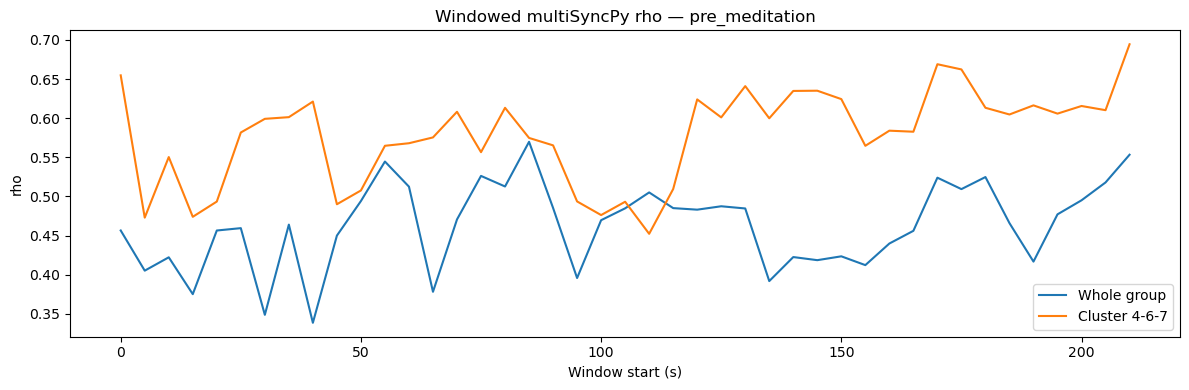

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/multisyncpy_windowed_rho_pre_meditation.png


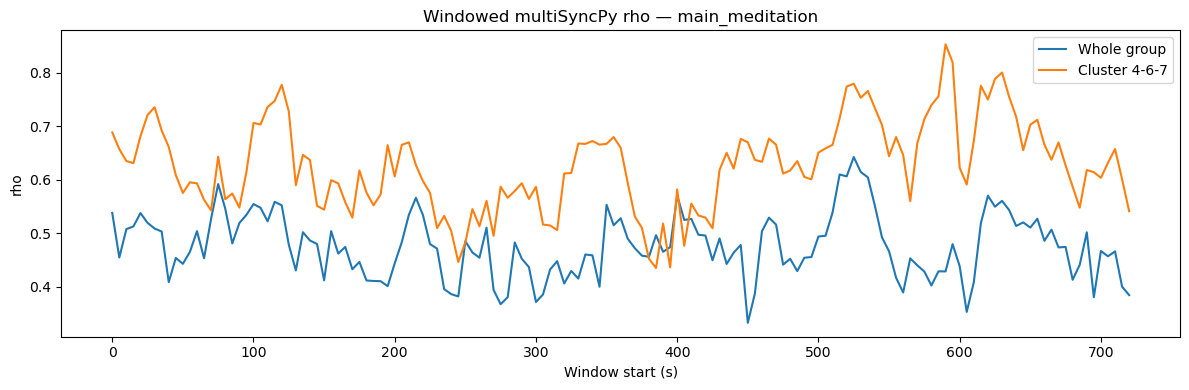

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/multisyncpy_windowed_rho_main_meditation.png


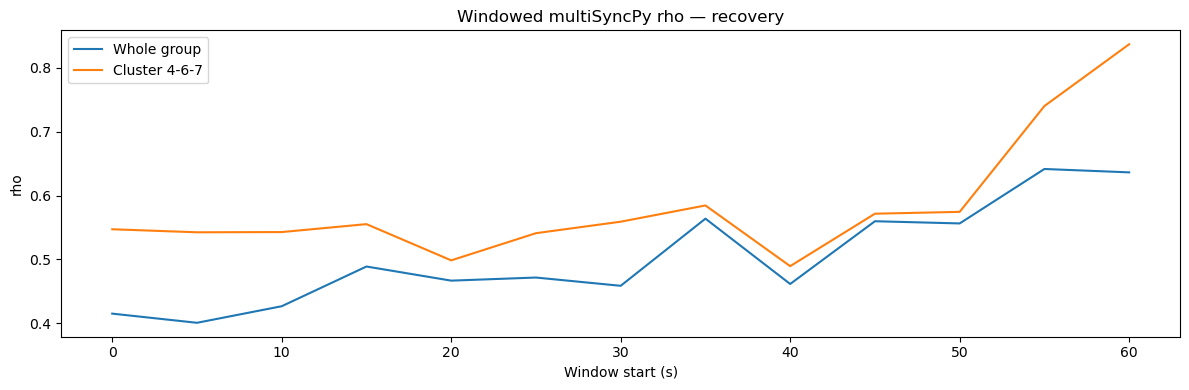

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/multisyncpy_windowed_rho_recovery.png


In [13]:
for segment in SEGMENTS:
    sub = windowed_rho_df[windowed_rho_df["segment"] == segment].copy()
    if len(sub) == 0:
        continue

    plt.figure(figsize=(12, 4))
    plt.plot(sub["window_start_sec"], sub["whole_rho_mean"], label="Whole group")
    plt.plot(sub["window_start_sec"], sub["cluster467_rho_mean"], label="Cluster 4-6-7")

    plt.title(f"Windowed multiSyncPy rho — {segment}")
    plt.xlabel("Window start (s)")
    plt.ylabel("rho")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"multisyncpy_windowed_rho_{segment}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [14]:
final_table = rho_summary.copy()

display(final_table)

,segment,whole_rho_mean,whole_rho_ts_mean,whole_rho_ts_std,cluster467_rho_mean,cluster467_rho_ts_mean,cluster467_rho_ts_std
0,pre_meditation,0.377058,0.377058,0.196335,0.537006,0.537006,0.233914
1,main_meditation,0.417731,0.417731,0.190428,0.645230,0.645230,0.246436
2,recovery,0.404090,0.404090,0.179660,0.491454,0.491454,0.215616


In [15]:
out_path = TABLES_DIR / "multisyncpy_rho_final_table.csv"
final_table.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/multisyncpy_rho_final_table.csv


In [16]:
print("=== multiSyncPy rho-only first pass ===")
print("Questions to inspect:")
print("1. Is cluster 4-6-7 rho higher than whole-group rho?")
print("2. Is rho highest during main meditation?")
print("3. Does the windowed rho plot show stronger subgroup coordination during meditation?")
print()
print("This notebook is descriptive only.")
print("If rho looks promising, the next step is surrogate testing for rho.")
print()
print("Reminder kept for later:")
print("Add a spectrogram/time-frequency figure in a later notebook for professor presentation.")

=== multiSyncPy rho-only first pass ===
Questions to inspect:
1. Is cluster 4-6-7 rho higher than whole-group rho?
2. Is rho highest during main meditation?
3. Does the windowed rho plot show stronger subgroup coordination during meditation?

This notebook is descriptive only.
If rho looks promising, the next step is surrogate testing for rho.

Reminder kept for later:
Add a spectrogram/time-frequency figure in a later notebook for professor presentation.
